In [ ]:
pip install pdfplumber

  Using cached pdfminer.six-20220319-py3-none-any.whl (5.6 MB)
  Attempting uninstall: pdfminer.six
    Found existing installation: pdfminer.six 20191110
    Uninstalling pdfminer.six-20191110:
      Successfully uninstalled pdfminer.six-20191110
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
textract 1.6.5 requires pdfminer.six==20191110, but you have pdfminer-six 20220319 which is incompatible.


In [ ]:
import pdfplumber

In [ ]:
pdfToString = ""
eng_word_lengths= []
with pdfplumber.open("erman_english.pdf") as eng_pdf:

      for page in eng_pdf.pages:
        eng_word_length = len(page.extract_text())
        eng_word_lengths.append(eng_word_length)
        print(eng_word_lengths)
        pdfToString += page.extract_text()

[4472]
[4472, 4136]
[4472, 4136, 4244]
[4472, 4136, 4244, 4216]
[4472, 4136, 4244, 4216, 4257]
[4472, 4136, 4244, 4216, 4257, 4256]
[4472, 4136, 4244, 4216, 4257, 4256, 2096]


In [ ]:
eng_word_lengths.append(0)

In [ ]:
english_word = len(re.findall(r'\w+', pdfToString))

In [ ]:
print ("The number of words in string are : " +  str(english_word))

The number of words in string are : 4291


In [ ]:
pdfToGerString = ""
ger_word_lens= []
with pdfplumber.open("german-converted.pdf") as german_pdf:
    for page in german_pdf.pages:

      ger_word_len =len(page.extract_text())
      ger_word_lens.append(ger_word_len)
      print(ger_word_lens)
      #print(ger_word_len =len(page.extract_text()))
      pdfToGerString += page.extract_text()

[4123]
[4123, 4267]
[4123, 4267, 4075]
[4123, 4267, 4075, 4161]
[4123, 4267, 4075, 4161, 4289]
[4123, 4267, 4075, 4161, 4289, 3996]
[4123, 4267, 4075, 4161, 4289, 3996, 3995]
[4123, 4267, 4075, 4161, 4289, 3996, 3995, 2718]


In [ ]:
ger_word_lens

[4123, 4267, 4075, 4161, 4289, 3996, 3995, 2718]

In [ ]:
german_word = len(re.findall(r'\w+', pdfToGerString))

In [ ]:
print ("The number of words in string are : " +  str(german_word))

The number of words in string are : 4285


In [ ]:
import pandas as pd

In [ ]:
data =  {'English_word':eng_word_lengths, 'German_word':ger_word_lens }
my_data = pd.DataFrame(data)

In [ ]:
my_data

,English_word,German_word
0,4472,4123
1,4136,4267
2,4244,4075
3,4216,4161
4,4257,4289
5,4256,3996
6,2096,3995
7,0,2718


In [ ]:
eng_word_mean =my_data['English_word'].mean()

In [ ]:
eng_word_stand_deviation =my_data['English_word'].std()

In [ ]:
eng_word_var =my_data['English_word'].var()

In [ ]:
ger_word_mean =my_data['German_word'].mean()
ger_word_mean

3953.0

In [ ]:
ger_word_stand_deviation =my_data['German_word'].std()
ger_word_stand_deviation

510.93443806421976

In [ ]:
ger_word_var =my_data['German_word'].var()
ger_word_var

261054.0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, stats

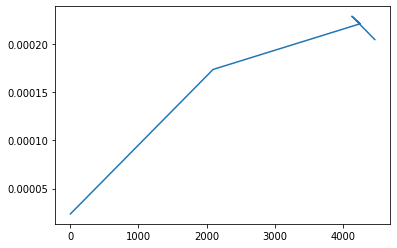

In [ ]:

plt.plot(my_data['English_word'], norm.pdf(my_data['English_word'], mean, stand_deviation))
plt.show()

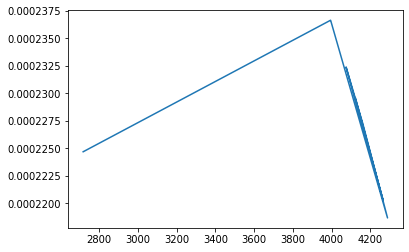

In [ ]:
plt.plot(my_data['German_word'], norm.pdf(my_data['German_word'], mean, stand_deviation))
plt.show()

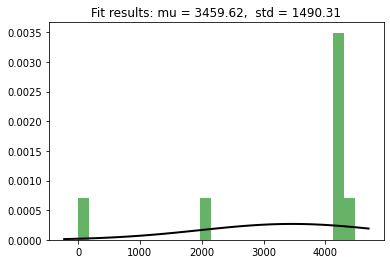

In [ ]:
# Fit a normal distribution to the data:
mu, std = norm.fit(my_data['English_word'])

# Plot the histogram.
plt.hist(my_data['English_word'], bins=25, density=True, alpha=0.6, color='g')

# Plot the PDF.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
title = "Fit results: mu = %.2f,  std = %.2f" % (mu, std)
plt.title(title)

plt.show()

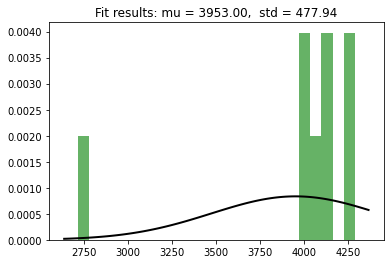

In [ ]:
# Fit a normal distribution to the data:
mu, std = norm.fit(my_data['German_word'])

# Plot the histogram.
plt.hist(my_data['German_word'], bins=25, density=True, alpha=0.6, color='g')

# Plot the PDF.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
title = "Fit results: mu = %.2f,  std = %.2f" % (mu, std)
plt.title(title)

plt.show()

In [ ]:
result =stats.ttest_rel(my_data['English_word'], my_data['German_word'])

In [ ]:
result

Ttest_relResult(statistic=-1.211622788143163, pvalue=0.26496525045809777)

In [ ]:
result =stats.ttest_rel()